# AMLGuard: Anti-Money Laundering Detection under Extreme Class Imbalance

**Author:** Caio Bernardinelli  
**Date:** June 2026  
**Course:** Técnico em Inteligência Artificial — IFNMG  
**Objective:** Build an ML classifier to detect money laundering transactions
in the IBM AML dataset under extreme class imbalance (< 1% positive class).

---

## 1. Dataset Presentation

### Business Context

In 2025, the European Union centralized anti-money laundering enforcement
under the **AMLA (Authority for Anti-Money Laundering)**, operational since
July 2025 and based in Frankfurt. As of January 2026, AMLA assumed mandates
previously held by the EBA, and from 2028 will directly supervise ~40
high-risk cross-border institutions.

The core technical challenge: **illicit transactions represent less than 1%
of total volume** — a classic extreme class imbalance problem. Current systems
generate too many false positives, overwhelming compliance analysts.

### Dataset

**Source:** IBM Transactions for Anti-Money Laundering (AML)  
**Link:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml  
**License:** Community Data License Agreement - Sharing - Version 1.0  
**Version used:** HI-Small (High Illicit ratio — smallest version for rapid iteration)

### Variable Description

| Column | Type | Description |
|--------|------|-------------|
| Timestamp | object | Date and time of the transaction |
| From Bank | int64 | ID of the sending bank |
| Account | object | Account number of the sender |
| To Bank | int64 | ID of the receiving bank |
| Account.1 | object | Account number of the receiver |
| Amount Received | float64 | Amount received by the destination account |
| Receiving Currency | object | Currency of the received amount |
| Amount Paid | float64 | Amount paid by the source account |
| Payment Currency | object | Currency of the paid amount |
| Payment Format | object | Payment method (e.g. Cheque, Wire, Reinvestment) |
| Is Laundering | int64 | **Target variable** — 1 = illicit, 0 = legitimate |

---

In [1]:
# ============================================================================
# SETUP & IMPORTS
# ============================================================================

import warnings
warnings.filterwarnings('ignore')
import gdown

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability
import shap

# Global random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully")
print(f"✓ Random state fixed: {RANDOM_STATE}")

✓ All libraries imported successfully
✓ Random state fixed: 42


## 2. Data Loading

The `HI-Small_Trans.csv` file is ~476 MB and is hosted on Google Drive rather than committed to the repository (the `.gitignore` excludes `*.csv`). It is downloaded at runtime with `gdown`, so the notebook is fully reproducible from a fresh clone: anyone running it fetches the data automatically, without needing the file in version control.

After loading, we run a first inspection — shape, column names, data types, memory footprint, and the distribution of the target variable — to confirm the data arrived intact and to quantify the class imbalance before any analysis.

In [10]:
# ============================================================================
# 2. DATA LOADING
# ============================================================================

print("="*80)
print("2. DATA LOADING")
print("="*80)

file_id = '1359N_tsRuUtCFMWCV6BtHjDdF280rb8e'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'HI-Small_Trans.csv', quiet=False)


df = pd.read_csv('HI-Small_Trans.csv')
print(df.shape)
print(df.columns.tolist())


# Basic inspection
print(f"\n✓ Dataset loaded successfully!")
print(f"\n{'─'*40}")
print(f"Shape:        {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"{'─'*40}")

print(f"\n--- First 10 rows ---")
print(df.head(10))

print(f"\n--- Data types ---")
print(df.dtypes)

print(f"\n--- Target variable (Is Laundering) ---")
print(df['Is Laundering'].value_counts())
print(f"\nIllicit transactions: {df['Is Laundering'].mean()*100:.4f}%")

2. DATA LOADING


Downloading...
From (original): https://drive.google.com/uc?id=1359N_tsRuUtCFMWCV6BtHjDdF280rb8e
From (redirected): https://drive.google.com/uc?id=1359N_tsRuUtCFMWCV6BtHjDdF280rb8e&confirm=t&uuid=24be5428-0a08-47e7-9151-262002e67a60
To: /content/HI-Small_Trans.csv
100%|██████████| 476M/476M [00:05<00:00, 81.9MB/s]


(5078345, 11)
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

✓ Dataset loaded successfully!

────────────────────────────────────────
Shape:        5,078,345 rows × 11 columns
Memory usage: 1890.96 MB
────────────────────────────────────────

--- First 10 rows ---
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   
5  2022/09/01 00:03          1  8000F5AD0        1  8000F5AD0   
6  2022/09/01 00:08          1  8000EBAC0        1  8000EBAC0   
7  2022/09/01 00:16          1  8000EC1E0        1  8000EC1E0   
8  2022/09/01 00:26    

**Key finding — the imbalance is even more extreme than expected.**

The dataset holds **5,078,345 transactions** across 11 columns. Only **5,177** are labelled as laundering — **0.1019%** of the total, roughly one illicit transaction in every 980. This is well below the "under 1%" rule of thumb and sets the methodological constraints for the entire pipeline: stratified train/test split, precision–recall-oriented metrics (PR-AUC) instead of accuracy, and explicit handling of imbalance (class weighting / resampling) during modelling.

## 3. Descriptive Analysis

Before modelling, we characterise the data and test three hypotheses about *where* laundering concentrates. Given the extreme imbalance (base rate 0.1019%), the guiding principle throughout this section is to compare **illicit rate**, not raw counts: a frequent category will naturally contain more illicit cases in absolute terms simply because it contains more of everything. What signals risk is a group whose *proportion* of laundering sits well above the global base rate.

Each hypothesis below follows the same pattern — derive a flag, group by it, and read the mean of the target (which, for a 0/1 column, is the illicit rate of the group).

In [19]:
# ============================================================================
# 3. DESCRIPTIVE ANALYSIS
# ============================================================================

print("="*80)
print("3. DESCRIPTIVE ANALYSIS")
print("="*80)

# --- 3.1 Numeric overview ---
print("\n--- Amount Paid / Received: statistics ---")
print(df[['Amount Paid', 'Amount Received']].describe())

# --- 3.2 Categorical cardinality ---
print("\n--- Cardinality of categorical variables ---")
for col in ['Receiving Currency', 'Payment Currency', 'Payment Format', 'From Bank', 'To Bank']:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n--- Payment Format distribution ---")
print(df['Payment Format'].value_counts())

print("\n--- Top 10 currencies (Payment) ---")
print(df['Payment Currency'].value_counts().head(10))

3. DESCRIPTIVE ANALYSIS

--- Amount Paid / Received: statistics ---
        Amount Paid  Amount Received
count  5.078345e+06     5.078345e+06
mean   4.509273e+06     5.988726e+06
std    8.697728e+08     1.037183e+09
min    1.000000e-06     1.000000e-06
25%    1.844800e+02     1.833700e+02
50%    1.414540e+03     1.411010e+03
75%    1.229784e+04     1.234627e+04
max    1.046302e+12     1.046302e+12

--- Cardinality of categorical variables ---
Receiving Currency: 15 unique values
Payment Currency: 15 unique values
Payment Format: 7 unique values
From Bank: 30470 unique values
To Bank: 15811 unique values

--- Payment Format distribution ---
Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64

--- Top 10 currencies (Payment) ---
Payment Currency
US Dollar      1895172
Euro           1168297
Swiss Franc     234860
Yuan            2137

### H1 — Cross-currency transactions

**Hypothesis:** moving money across currencies (paid ≠ received currency) could help shift wealth across borders and hinder tracing.

**Reading:** the hypothesis **cannot be tested on this dataset**. Cross-currency transactions are only 1.42% of all records (72,170 of 5.08M), and — decisively — **none** of them are labelled as laundering (0 illicit in 72,170). All 5,177 illicit cases are same-currency. This is a property of the synthetic generator, which never tags a cross-currency transaction as illicit, rather than an economic pattern. The flag therefore acts as a perfect *negative* predictor (cross-currency ⇒ certainly legitimate), which is a simulator artifact and not a generalizable signal. It will be **excluded** from modelling to avoid leakage, and noted as a dataset limitation in the conclusion.

In [26]:
df['is_cross_currency'] = (df['Payment Currency'] != df['Receiving Currency']).astype(int)
df.groupby('is_cross_currency')['Is Laundering'].agg(['mean', 'count', 'sum'])


,mean,count,sum
is_cross_currency,,,
0,0.001034,5006175,5177
1,0.000000,72170,0


In [27]:
print("--- Is_cross_currency distribuition ---")
print(df['is_cross_currency'].value_counts(normalize=True) * 100)


--- Is_cross_currency distribuition ---
is_cross_currency
0    98.578868
1     1.421132
Name: proportion, dtype: float64


### H2 — Payment format and laundering

**Hypothesis:** some payment methods offer easier laundering channels, so their illicit rate should exceed the global base rate (0.1019%).

**Reading:** only **ACH** stands out. Its illicit rate is **0.7462%** — about **7.3× the global base rate** — and it concentrates **86.6%** of all illicit cases. Crucially, the intuition that low-traceability channels (Bitcoin, Cash) would lead does **not** hold here: Bitcoin (0.0383%) and Cash (0.0220%) sit *below* the base rate, so a transaction in those formats is, if anything, *less* likely to be illicit than average. Their apparent prominence among illicit cases was a volume artifact (Reading B), not elevated risk (Reading A). Two formats — Reinvestment and Wire — contain **zero** illicit cases across hundreds of thousands of transactions, mirroring the generator-rule pattern seen in H1. ACH is therefore the only payment-format signal worth keeping as a feature, but its 7× concentration likely reflects how the synthetic generator routes laundering events rather than a real-world property of ACH, and is flagged as a dataset bias in the conclusion.

In [16]:
df.groupby('Payment Format')['Is Laundering'].agg(['mean', 'count', 'sum'])

,mean,count,sum
Payment Format,,,
ACH,0.007462,600797,4483
Bitcoin,0.000383,146091,56
Cash,0.000220,490891,108
Cheque,0.000174,1864331,324
Credit Card,0.000156,1323324,206
Reinvestment,0.000000,481056,0
Wire,0.000000,171855,0


In [28]:
fmt = df.groupby('Payment Format')['Is Laundering'].agg(['mean', 'count', 'sum'])

fmt = fmt.rename(columns={
    'mean':  'illicit_rate',     # illicit rate WITHIN the format (Reading A)
    'count': 'n_transactions',   # total volume of the format
    'sum':   'n_illicit'         # absolute illicit count
})

# Reading A — illicit rate within the format, as %
fmt['illicit_rate_%'] = (fmt['illicit_rate'] * 100).round(4)

# Legitimate rate within the format (complement of the illicit rate)
fmt['legit_rate_%'] = (100 - fmt['illicit_rate_%']).round(4)

# Reading B — how much each format represents of all illicit cases
fmt['%_of_all_illicit'] = (fmt['n_illicit'] / fmt['n_illicit'].sum() * 100).round(2)

# Context — how much each format represents of total volume
fmt['%_of_all_tx'] = (fmt['n_transactions'] / fmt['n_transactions'].sum() * 100).round(2)

fmt = fmt[['n_transactions', '%_of_all_tx', 'n_illicit',
           '%_of_all_illicit', 'illicit_rate_%', 'legit_rate_%']]
fmt = fmt.sort_values('illicit_rate_%', ascending=False)

print(f"Global base rate: {df['Is Laundering'].mean()*100:.4f}%\n")
print(fmt)

Global base rate: 0.1019%

                n_transactions  %_of_all_tx  n_illicit  %_of_all_illicit  \
Payment Format                                                             
ACH                     600797        11.83       4483             86.59   
Bitcoin                 146091         2.88         56              1.08   
Cash                    490891         9.67        108              2.09   
Cheque                 1864331        36.71        324              6.26   
Credit Card            1323324        26.06        206              3.98   
Reinvestment            481056         9.47          0              0.00   
Wire                    171855         3.38          0              0.00   

                illicit_rate_%  legit_rate_%  
Payment Format                                
ACH                     0.7462       99.2538  
Bitcoin                 0.0383       99.9617  
Cash                    0.0220       99.9780  
Cheque                  0.0174       99.9826  
Credit

### H3 — Same-bank vs. cross-bank transactions

**Hypothesis:** transactions between different banks/accounts could ease laundering, since an offender may push funds toward accounts where the money can be withdrawn with less direct traceability.

**Reading:** the direction holds, but the effect is **weak**. Cross-bank transactions show an illicit rate of **0.1157%** versus **0.0149%** for same-bank ones — so same-bank movement is ~7× *less* likely to be illicit, consistent with the idea that laundering favors moving funds across institutions. However, the cross-bank rate is only **1.14× the global base rate** (0.1019%), a modest lift compared with ACH's 7.3×. The "98% of illicit cases are cross-bank" figure is misleading on its own, since 86% of *all* transactions are already cross-bank; the real evidence is the rate increase, not the volume. `same_bank` is therefore a weak-but-valid feature, kept for modelling but not over-interpreted.

In [15]:
df['same_bank'] = (df['From Bank'] == df['To Bank']).astype(int)
df.groupby('same_bank')['Is Laundering'].agg(['mean', 'count', 'sum'])

,mean,count,sum
same_bank,,,
0,0.001157,4387013,5074
1,0.000149,691332,103


In [29]:
same_bank = df.groupby('same_bank')['Is Laundering'].agg(['mean', 'count', 'sum'])
same_bank = same_bank.rename(columns={'mean': 'illicit_rate', 'count': 'n_transactions', 'sum': 'n_illicit'})
same_bank['illicit_rate_%'] = (same_bank['illicit_rate'] * 100).round(4)
same_bank['%_of_all_tx'] = (same_bank['n_transactions'] / same_bank['n_transactions'].sum() * 100).round(2)
same_bank['%_of_all_illicit'] = (same_bank['n_illicit'] / same_bank['n_illicit'].sum() * 100).round(2)
same_bank = same_bank.rename(index={0: 'Different banks', 1: 'Same bank'})
print(f"Global base rate: {df['Is Laundering'].mean()*100:.4f}%\n")
print(same_bank[['n_transactions', '%_of_all_tx', 'n_illicit', '%_of_all_illicit', 'illicit_rate_%']])

Global base rate: 0.1019%

                 n_transactions  %_of_all_tx  n_illicit  %_of_all_illicit  \
same_bank                                                                   
Different banks         4387013        86.39       5074             98.01   
Same bank                691332        13.61        103              1.99   

                 illicit_rate_%  
same_bank                        
Different banks          0.1157  
Same bank                0.0149  


**Section summary**

Of the three hypotheses tested, only one produced a usable real signal, and a fourth lesson — methodological — runs through all of them: **always compare illicit *rate* within a group, never raw counts**, because frequent categories accumulate illicit cases simply by being frequent.

- **H1 — Cross-currency:** not testable on this dataset. Cross-currency transactions are 1.42% of the data and contain **zero** illicit cases, so the flag is a perfect *negative* predictor (cross-currency ⇒ certainly legitimate). This is a generator artifact, not an economic pattern — the feature is **excluded** to avoid leakage.
- **H2 — Payment format:** only **ACH** stands out, with an illicit rate of 0.7462% (**7.3× the base rate**) and 86.6% of all illicit cases. The low-traceability intuition (Bitcoin, Cash) did **not** hold — both sit *below* the base rate; their prominence was a volume artifact. ACH is kept as the strongest format signal, though its concentration likely reflects how the synthetic generator routes laundering events.
- **H3 — Same vs. cross-bank:** the hypothesized direction holds but the effect is **weak**. Cross-bank transactions reach 0.1157% illicit rate versus 0.0149% for same-bank — only **1.14× the base rate**. Kept as a weak-but-valid feature.

**Implication for modelling:** the global base rate of 0.1019% means accuracy is meaningless here; evaluation will rely on PR-AUC and recall at fixed precision. The strongest available signal (ACH) and the recurring presence of generator artifacts (zero-illicit groups) are both flagged as dataset limitations in the conclusion. Two formats (Reinvestment, Wire) and the entire cross-currency group contain no illicit cases at all — a reminder that on synthetic data, every strong signal must be questioned as *real pattern vs. simulator rule*.

## 4. Data Cleaning

This dataset is synthetic and generated by IBM's multi-agent simulator, so it is expected to arrive with high integrity and without the noise typical of real-world financial data. Rather than assuming this, the checks below verify it explicitly: missing values, exact duplicates, data types, and timestamp parseability.

> **Note on ordering:** cleaning is presented after the descriptive analysis (Section 3) for narrative flow, but the checks below confirm the dataset was already complete and well-typed — so the Section 3 conclusions rest on untreated, intact data, with no risk of contamination from missing or malformed values.

In [30]:
# ============================================================================
# 4. DATA CLEANING
# ============================================================================

print("="*80)
print("4. DATA CLEANING")
print("="*80)

# --- 4.1 Missing values ---
print("\n--- Missing values per column ---")
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_table = pd.DataFrame({'n_missing': missing, 'pct_%': missing_pct})
print(missing_table[missing_table['n_missing'] > 0] if missing.sum() > 0 else "No missing values found.")

# --- 4.2 Duplicates (full-row) ---
print("\n--- Full-row duplicates ---")
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.4f}%)")

# --- 4.3 Data types check ---
print("\n--- Current dtypes ---")
print(df.dtypes)

# --- 4.4 Timestamp parsing check ---
print("\n--- Timestamp: parseable check ---")
parsed = pd.to_datetime(df['Timestamp'], errors='coerce')
print(f"Failed to parse: {parsed.isna().sum():,} of {len(df):,}")
print(f"Date range: {parsed.min()} → {parsed.max()}")

4. DATA CLEANING

--- Missing values per column ---
No missing values found.

--- Full-row duplicates ---
Exact duplicate rows: 9 (0.0002%)

--- Current dtypes ---
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
same_bank               int64
is_cross_currency       int64
dtype: object

--- Timestamp: parseable check ---
Failed to parse: 0 of 5,078,345
Date range: 2022-09-01 00:00:00 → 2022-09-18 16:18:00


**Cleaning decisions**

| Check | Result | Decision & justification |
|---|---|---|
| Missing values | 0 across all 11 columns | No imputation required — the dataset is complete. |
| Exact duplicate rows | 9 rows (0.0002%) | **Kept.** Identical rows in a transaction log may be legitimate repeated payments; with only 9 cases in 5.08M, there is no evidence they are errors and no measurable impact, so they were preserved and documented rather than dropped on assumption. |
| Data types | All consistent; `Timestamp` stored as object | Will be parsed to datetime in Section 5 for temporal feature extraction. |
| Timestamp parseability | 100% parseable (0 failures) | Range: 2022-09-01 → 2022-09-18 — a dense 18-day window, relevant for velocity-based features in Section 5. |

**Conclusion:** The dataset required no cleaning. Being synthetic and generated under controlled conditions, it arrived complete (zero missing values), well-typed, and with fully parseable timestamps. No values were imputed and no rows were dropped; the only observation of note is 9 exact duplicates (0.0002%), kept as plausibly legitimate. This confirms that the Section 3 conclusions rest on intact data.

## 5. Exploratory Data Analysis & Feature Engineering

This section has two goals: (1) visualise how the main variables distribute across the two classes, and (2) turn the validated signals from Section 3 into model-ready features. The guiding question throughout remains *what distinguishes the <0.11% illicit minority?* Every candidate feature is judged by the same rule used in Section 3 — illicit **rate** within a group versus the global base rate (0.1019%), never raw counts.

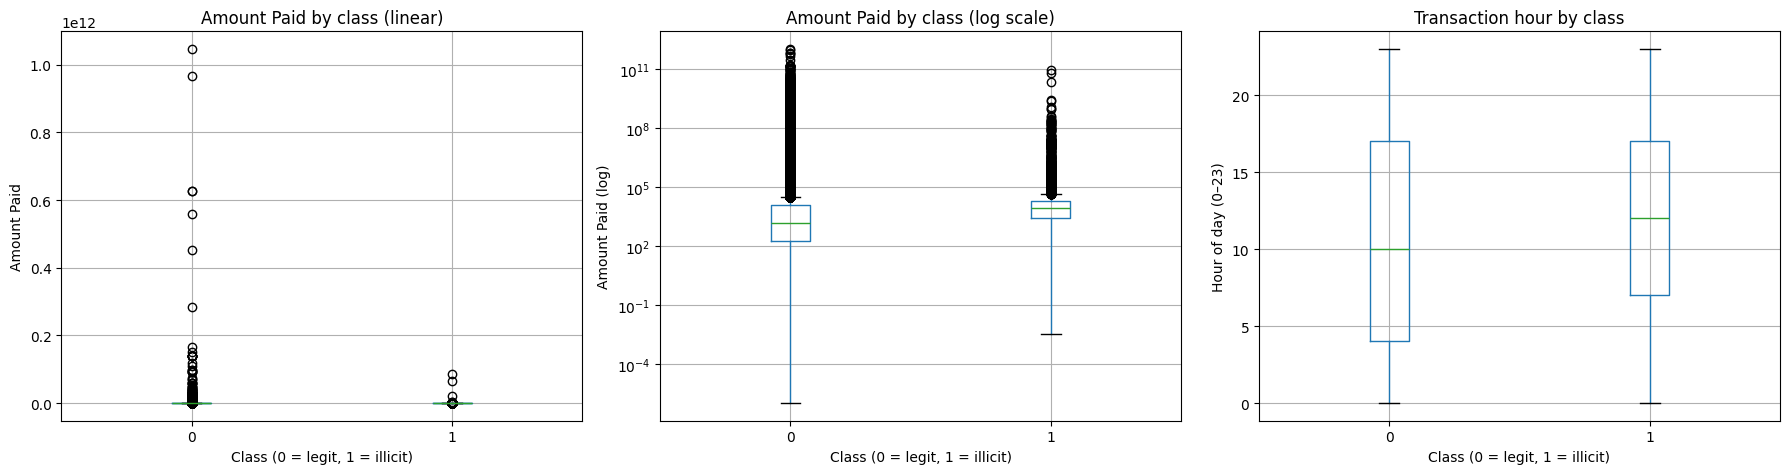

Global base rate: 0.1019%

       count  sum  illicit_rate_%
Hour                             
0     634726  176          0.0277
1     193728  152          0.0785
2     193143  165          0.0854
3     193249  146          0.0756
4     193166  154          0.0797
5     193900  188          0.0970
6     194456  207          0.1065
7     193336  195          0.1009
8     192921  258          0.1337
9     192952  217          0.1125
10    193229  234          0.1211
11    193500  295          0.1525
12    192972  336          0.1741
13    192521  292          0.1517
14    192787  279          0.1447
15    194871  263          0.1350
16    193407  311          0.1608
17    193154  257          0.1331
18    193321  255          0.1319
19    192824  231          0.1198
20    192809  134          0.0695
21    192192  154          0.0801
22    191836  128          0.0667
23    193345  150          0.0776


In [33]:
# ============================================================================
# 5. EXPLORATORY DATA ANALYSIS — distributions by class
# ============================================================================

# Ensure datetime + hour are available
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 5.1 Amount by class (linear scale) ---
df.boxplot(column='Amount Paid', by='Is Laundering', ax=axes[0])
axes[0].set_title('Amount Paid by class (linear)')
axes[0].set_xlabel('Class (0 = legit, 1 = illicit)')
axes[0].set_ylabel('Amount Paid')

# --- 5.2 Amount by class (log scale — reveals structure in long tails) ---
df.boxplot(column='Amount Paid', by='Is Laundering', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Amount Paid by class (log scale)')
axes[1].set_xlabel('Class (0 = legit, 1 = illicit)')
axes[1].set_ylabel('Amount Paid (log)')

# --- 5.3 Hour of day by class ---
df.boxplot(column='Hour', by='Is Laundering', ax=axes[2])
axes[2].set_title('Transaction hour by class')
axes[2].set_xlabel('Class (0 = legit, 1 = illicit)')
axes[2].set_ylabel('Hour of day (0–23)')

plt.suptitle('')  # remove auto title
plt.tight_layout()
plt.show()

hourly = df.groupby('Hour')['Is Laundering'].agg(['count', 'sum', 'mean'])
hourly['illicit_rate_%'] = (hourly['mean'] * 100).round(4)
print(f"Global base rate: {df['Is Laundering'].mean()*100:.4f}%\n")
print(hourly[['count', 'sum', 'illicit_rate_%']])

**5.1 Distributions by class**

**Transaction amount.** On a linear scale, legitimate transactions contain extreme outliers (up to ~1×10¹²), which compress the bulk of the data and make the classes visually indistinguishable. On a **log scale**, a faint structure emerges: illicit amounts are slightly more concentrated and avoid both the smallest and the largest values, sitting in a mid-range band. Overall, **amount alone is a weak discriminator** — it does not cleanly separate the classes, confirming the earlier observation from Section 3. The log scale is kept deliberately: with values spanning 14 orders of magnitude, it is the only view that shows the full distribution without hiding the heavy tail.

**Transaction hour.** Although the hour-of-day boxplots look identical for both classes, the illicit *rate* per hour reveals a clear daily structure. Illicit activity is lowest overnight (00h–05h: 0.03–0.08%, below the base rate) and concentrates during **business hours** (08h–18h: 0.13–0.17%, above the base rate), peaking at 12h (0.1741%, ~1.7× the base rate). This **contradicts the original "unusual-hour" hypothesis**: laundering here aligns with normal business-hours flow rather than the early morning — consistent with blending into legitimate volume, though on synthetic data this may equally reflect the generator's design. Transaction counts are uniform across hours (~193k each), so the rate variation is genuine and not a volume artifact. *(Note: 00h holds ~3× the volume of other hours — likely transactions defaulted to midnight by the generator, a minor data-quality observation.)*

In [34]:
# Round-value flags at different granularities
df['round_100']  = (df['Amount Paid'] % 100 == 0).astype(int)
df['round_1000'] = (df['Amount Paid'] % 1000 == 0).astype(int)

base = df['Is Laundering'].mean() * 100
print(f"Global base rate: {base:.4f}%\n")

for col in ['round_100', 'round_1000']:
    print(f"--- {col} ---")
    t = df.groupby(col)['Is Laundering'].agg(['count', 'sum', 'mean'])
    t['illicit_rate_%'] = (t['mean'] * 100).round(4)
    print(t[['count', 'sum', 'illicit_rate_%']])
    print()

Global base rate: 0.1019%

--- round_100 ---
             count   sum  illicit_rate_%
round_100                               
0          5077718  5176          0.1019
1              627     1          0.1595

--- round_1000 ---
              count   sum  illicit_rate_%
round_1000                               
0           5078277  5177          0.1019
1                68     0          0.0000



In [35]:
# Velocity (simplified): number of transactions per sending account
acc_tx_count = df.groupby('Account')['Is Laundering'].transform('count')
df['sender_tx_count'] = acc_tx_count

# Compare illicit rate across velocity bands
df['velocity_band'] = pd.cut(df['sender_tx_count'],
                              bins=[0, 1, 5, 20, 100, float('inf')],
                              labels=['1', '2-5', '6-20', '21-100', '100+'])

base = df['Is Laundering'].mean() * 100
print(f"Global base rate: {base:.4f}%\n")
vb = df.groupby('velocity_band')['Is Laundering'].agg(['count', 'sum', 'mean'])
vb['illicit_rate_%'] = (vb['mean'] * 100).round(4)
print(vb[['count', 'sum', 'illicit_rate_%']])

Global base rate: 0.1019%

                 count   sum  illicit_rate_%
velocity_band                               
1               152750   122          0.0799
2-5             534753  1857          0.3473
6-20            603101   836          0.1386
21-100         2856269  1546          0.0541
100+            931472   816          0.0876


**5.2 Feature engineering**

Each candidate feature below is derived from the hypotheses and tested against the global base rate (0.1019%). Signals that proved to be generator artifacts or statistical noise are deliberately excluded to avoid leakage and overfitting.

**Payment format (ACH) — kept, strongest signal.** ACH shows an illicit rate of 0.7462% (~7.3× the base rate) and concentrates 86.6% of all illicit cases. The low-traceability intuition (Bitcoin, Cash) did not hold — both sit *below* the base rate. Kept as a one-hot encoded feature; ACH is the dominant format signal, likely reflecting how the generator routes laundering events.

**Velocity (transactions per sending account) — kept, strong and non-linear.** The illicit rate is *not* monotonic with activity. It peaks at accounts with **2–5 transactions (0.3473%, ~3.4× the base rate)** and drops *below* the base rate for highly active accounts (21–100: 0.0541%; 100+: 0.0876%). This contradicts the naive "more transactions = more suspicious" intuition: high-volume accounts are likely legitimate entities (businesses, payment processors), while laundering concentrates in low-to-moderate activity accounts — the signature of pass-through "mule" accounts. With 534k transactions and 1,857 illicit cases in the 2–5 band, the signal is robust. Kept as a numeric feature (`sender_tx_count`) for tree-based models to split on, since the relationship is non-monotonic.

**Business hours — kept, moderate signal.** Derived from the hourly analysis (5.1). An `is_business_hours` flag (08h–18h) captures the daily concentration of illicit activity (~1.7× the base rate at peak). Moderate strength, but a coherent and interpretable pattern rather than an isolated number.

**Same-bank — kept, weak signal.** Cross-bank transactions reach an illicit rate of 0.1157% versus 0.0149% for same-bank ones — only 1.14× the base rate. Weak but valid and directionally consistent with the hypothesis; kept without over-interpretation.

**Cross-currency — excluded (generator artifact).** Cross-currency transactions (1.42% of data) contain **zero** illicit cases, making the flag a perfect *negative* predictor. This is a property of the synthetic generator, not an economic pattern, and would leak. Excluded from modelling.

**Round-value flag — excluded (phenomenon absent).** Round amounts barely exist (627 multiples of 100 and 68 of 1,000 out of 5.08M, with 1 and 0 illicit cases). The hypothesis is sound in theory but untestable here — the generator produces organic amounts almost exclusively. Excluded.

**Summary of feature decisions:**

| Feature | Illicit rate | Strength vs base | Decision |
|---|---|---|---|
| Payment format (ACH) | 0.7462% | 7.3× | **Kept** — strongest |
| Velocity (2–5 band) | 0.3473% | 3.4× | **Kept** — non-linear |
| Business hours (peak) | 0.1741% | 1.7× | **Kept** — moderate |
| Same-bank (cross-bank) | 0.1157% | 1.14× | **Kept** — weak |
| Cross-currency | 0.0000% | — | **Excluded** — artifact |
| Round value | ~0% | — | **Excluded** — absent |

Of the original hypotheses, the data confirmed payment-format and (partially) same-bank, refuted the unusual-hour direction (revealing the opposite), surfaced an unanticipated non-linear velocity signal, and killed cross-currency and round-value for lack of the phenomenon. This is the core lesson of working with synthetic data: every strong signal must be questioned as *real pattern vs. simulator rule*.

In [37]:
# Same account (origin == destination) — is the money moving, or just reshuffling?
df['same_account'] = (df['Account'] == df['Account.1']).astype(int)

base = df['Is Laundering'].mean() * 100
print(f"Global base rate: {base:.4f}%\n")

# Illicit rate by same_account
sa = df.groupby('same_account')['Is Laundering'].agg(['count', 'sum', 'mean'])
sa['illicit_rate_%'] = (sa['mean'] * 100).round(4)
sa['%_of_all_tx'] = (sa['count'] / len(df) * 100).round(2)
print(sa[['count', '%_of_all_tx', 'sum', 'illicit_rate_%']].rename(
    index={0: 'Different accounts', 1: 'Same account'}))

# Is same_account just a proxy for Reinvestment? Cross-check.
print("--- same_account vs Payment Format ---")
print(pd.crosstab(df['same_account'], df['Payment Format']))

Global base rate: 0.1019%

                      count  %_of_all_tx   sum  illicit_rate_%
same_account                                                  
Different accounts  4487133        88.36  5166          0.1151
Same account         591212        11.64    11          0.0019
--- same_account vs Payment Format ---
Payment Format     ACH  Bitcoin    Cash   Cheque  Credit Card  Reinvestment  \
same_account                                                                  
0               529450   119774  489436  1858265      1319148             0   
1                71347    26317    1455     6066         4176        481056   

Payment Format    Wire  
same_account            
0               171060  
1                  795  


In [38]:
base = df['Is Laundering'].mean() * 100
print(f"Global base rate: {base:.4f}%\n")

# Illicit rate by sending bank — only banks with enough volume to be reliable
bank_stats = df.groupby('From Bank')['Is Laundering'].agg(['count', 'sum', 'mean'])
bank_stats['illicit_rate_%'] = (bank_stats['mean'] * 100).round(4)

# Filter: banks with at least 1000 transactions (avoid tiny-sample noise)
reliable = bank_stats[bank_stats['count'] >= 1000].sort_values('illicit_rate_%', ascending=False)
print(f"Banks with >=1000 transactions: {len(reliable)} of {len(bank_stats)} total\n")
print("--- Top 10 riskiest banks (by illicit rate) ---")
print(reliable.head(10))
print("\n--- How concentrated is illicit activity? ---")
print(f"Total banks: {df['From Bank'].nunique()}")
print(f"Banks with at least 1 illicit tx: {(bank_stats['sum'] > 0).sum()}")

Global base rate: 0.1019%

Banks with >=1000 transactions: 802 of 30470 total

--- Top 10 riskiest banks (by illicit rate) ---
           count  sum      mean  illicit_rate_%
From Bank                                      
148350      1362   31  0.022761          2.2761
213952      2165   33  0.015242          1.5242
11128       1166   14  0.012007          1.2007
249176      1454   15  0.010316          1.0316
19329       2779   25  0.008996          0.8996
15231       3780   33  0.008730          0.8730
48309       3160   27  0.008544          0.8544
7548        2325   19  0.008172          0.8172
210431      2140   17  0.007944          0.7944
214615      2173   17  0.007823          0.7823

--- How concentrated is illicit activity? ---
Total banks: 30470
Banks with at least 1 illicit tx: 1021


In [39]:
# Accounts that appear most in illicit transactions (as sender)
illicit = df[df['Is Laundering'] == 1]
print(f"Total illicit transactions: {len(illicit)}")
print(f"Unique sending accounts in illicit tx: {illicit['Account'].nunique()}")
print(f"Unique receiving accounts in illicit tx: {illicit['Account.1'].nunique()}")

print("\n--- Top 10 sending accounts by illicit count ---")
print(illicit['Account'].value_counts().head(10))

print("\n--- Top 10 receiving accounts by illicit count ---")
print(illicit['Account.1'].value_counts().head(10))

Total illicit transactions: 5177
Unique sending accounts in illicit tx: 3376
Unique receiving accounts in illicit tx: 3984

--- Top 10 sending accounts by illicit count ---
Account
100428660    243
1004286A8    158
80266F880     29
100428978     29
100428810     26
812D22980     25
100428738     23
100428780     21
8021353D0     21
811C599A0     21
Name: count, dtype: int64

--- Top 10 receiving accounts by illicit count ---
Account.1
811C599A0    31
8021353D0    28
811C597B0    23
80266F880    22
811ED7DF0    20
812A09CF0    19
811D80C30    18
811B83280    17
8028F2650    16
8079DDC30    16
Name: count, dtype: int64


### 5.3 Network structure of illicit activity (EDA insight, not a feature)

Beyond per-transaction flags, the concentration of illicit activity across banks and accounts was examined.

**Banks — no strong institutional concentration.** Illicit transactions are spread across 1,021 of 30,470 banks. Even the riskiest bank by volume reaches only 2.28× the base rate, and the signal fades below 1× past the top few. There is no small set of "facilitating banks" — so the original bank-level hypothesis (H3) does not hold as a strong signal, and individual bank IDs are **not** used as features (that would memorise dataset-specific IDs and leak).

**Accounts — strong concentration and a network signature.** The 5,177 illicit transactions originate from only 3,376 unique sending accounts. Concentration is extreme at the top: account `100428660` sends 243 illicit transactions and `1004286A8` sends 158 — together ~8% of all laundering in just two accounts. The top illicit senders share a near-sequential ID prefix (`100428...`), suggesting a family of mule accounts created together. Decisively, several accounts (e.g. `811C599A0`, `8021353D0`, `80266F880`) appear in the **top 10 of both senders and receivers** — the same accounts both send and receive illicit funds, the classic topology of a layering network where money circulates within a closed set of accounts.

**Implications:** (1) this explains *why* the velocity feature works — laundering concentrates in repeating mule accounts; (2) account IDs are deliberately **not** turned into features (leakage risk); (3) this is the concrete motivation for the graph-based extension (NetworkX) in the post-delivery roadmap, where these send/receive relationships become network features (centrality, cycles).

In [43]:
# Extract calendar day from timestamp
df['Date'] = df['Timestamp'].dt.date

# For each sending account: how many DISTINCT days it transacted
days_per_account = df.groupby('Account')['Date'].transform('nunique')
df['account_n_days'] = days_per_account

# Flag: account that operated on a single day only
df['single_day_account'] = (df['account_n_days'] == 1).astype(int)

base = df['Is Laundering'].mean() * 100
print(f"Global base rate: {base:.4f}%\n")

# THE RIGHT VIEW: illicit RATE within each group (rate, not volume)
print("--- Illicit rate by single-day vs multi-day accounts ---")
t = df.groupby('single_day_account')['Is Laundering'].agg(['count', 'sum', 'mean'])
t['illicit_rate_%'] = (t['mean'] * 100).round(4)
t['%_of_all_tx'] = (t['count'] / len(df) * 100).round(2)
print(t[['count', '%_of_all_tx', 'sum', 'illicit_rate_%']].rename(
    index={0: 'Multi-day account', 1: 'Single-day account'}))

# THE MISLEADING VIEW (for contrast): % of illicit that are single-day
illicit = df[df['Is Laundering'] == 1]
print(f"\n--- Contrast: of illicit tx, % from single-day accounts ---")
print((illicit['single_day_account'].value_counts(normalize=True) * 100).round(2))

Global base rate: 0.1019%

--- Illicit rate by single-day vs multi-day accounts ---
                      count  %_of_all_tx   sum  illicit_rate_%
single_day_account                                            
Multi-day account   4748113         93.5  4885          0.1029
Single-day account   330232          6.5   292          0.0884

--- Contrast: of illicit tx, % from single-day accounts ---
single_day_account
0    94.36
1     5.64
Name: proportion, dtype: float64


**Final feature selection**

After testing eight candidate features against the global base rate (0.1019%) — always by illicit *rate*, never raw count — the following set was selected for modelling. Three signals were kept, two engineered flags were dropped for redundancy or weakness, and three hypotheses were excluded because the data did not support them.

**Selected features (model inputs):**

| Feature | Type | Illicit rate (riskier group) | Strength vs base | Rationale |
|---|---|---|---|---|
| `Payment Format` (incl. ACH) | categorical (one-hot) | 0.7462% (ACH) | 7.3× | Strongest signal; ACH concentrates 86.6% of illicit cases |
| `sender_tx_count` | numeric | 0.3473% (2–5 band) | 3.4× | Non-linear velocity signal; mule-account signature |
| `is_business_hours` | binary | 0.1741% (peak 12h) | 1.7× | Illicit activity concentrates in business hours |
| `same_account` | binary | 0.1151% (diff. accounts) | 1.13× | Weak but sharp separation; money must move between accounts |
| `Amount Paid` | numeric | — | weak | Low standalone power, but retained as a baseline numeric input |

**Excluded features and why:**

| Feature | Reason for exclusion |
|---|---|
| `is_cross_currency` | Generator artifact — zero illicit in 72k cross-currency rows (perfect negative predictor → leakage) |
| `round_value` | Phenomenon absent — only 627 round amounts in 5.08M, no measurable signal |
| `single_day_account` | No signal — rate ≈ base rate; apparent concentration was a volume artifact |
| `same_bank` | Redundant with `same_account` (r = 0.914) — kept the sharper-resolution flag |
| `Amount Received` | Redundant with `Amount Paid` (r = 0.843) — one amount column suffices |
| Account / Bank IDs | Would memorise dataset-specific identifiers (leakage); concentration captured indirectly via velocity |

**Closing note.** Of the original hypotheses, the data confirmed payment-format strongly and same-account weakly, refuted the unusual-hour direction (laundering aligns with business hours, not the early morning), surfaced an unanticipated non-linear velocity signal, and rejected cross-currency, round-value, and single-day for lack of the phenomenon. Linear correlation with the target is near-zero for every feature, which — given the 0.1% positive class and non-monotonic relationships — is the central reason the modelling stage (Section 7) relies on tree-based models rather than linear methods. The strongest signals (ACH, velocity) are noted as likely reflecting the synthetic generator's design and are flagged as a dataset limitation in the conclusion.